# Function Transformation

### Importing libraries

In [41]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

### Loading dataset

In [10]:
df = pd.read_csv('E:/Dataset/titanic-Dataset.csv', usecols=['Survived','Age','Fare'])

In [15]:
df.sample(2)

,Survived,Age,Fare
389,1,17.0,12.000
816,0,23.0,7.925


#### Filling null value from dataset

In [16]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [18]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [20]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

### Splitting dataset

In [21]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=2)

### Analyzing data

In [35]:
import scipy.stats as stats

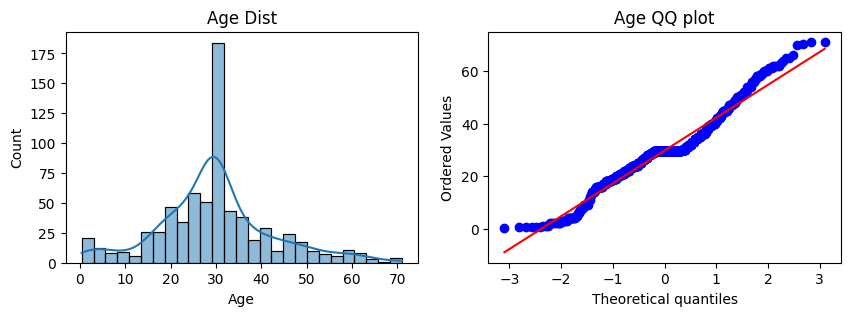

In [40]:
fig, axes = plt.subplots(1,2, figsize=(10,3))
sns.histplot(x_train['Age'], kde=True, ax=axes[0])
axes[0].set_title("Age Dist")

stats.probplot(x_train['Age'], dist='norm', plot=axes[1])
axes[1].set_title("Age QQ plot")

plt.show()

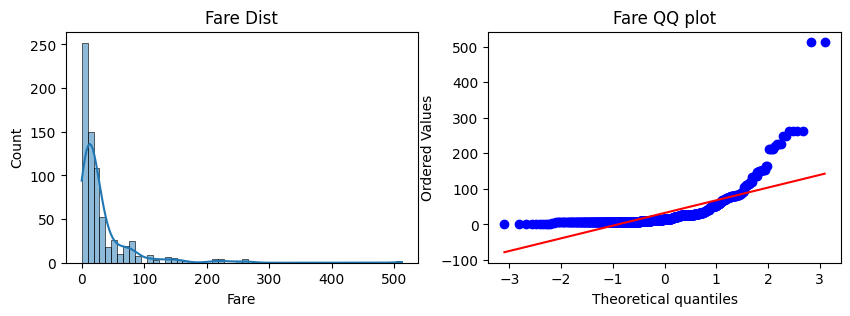

In [42]:
fig, axes = plt.subplots(1,2, figsize=(10,3))
sns.histplot(x_train['Fare'], kde=True, ax=axes[0])
axes[0].set_title("Fare Dist")

stats.probplot(x_train['Fare'], dist='norm', plot=axes[1])
axes[1].set_title("Fare QQ plot")

plt.show()

### Model without function transformation

In [63]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [64]:
clf.fit(x_train, y_train)
clf2.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [65]:
y_pred = clf.predict(x_test)
y_pred2 = clf2.predict(x_test)

In [66]:
print("Accuracy LR", accuracy_score(y_pred, y_test))
print("Accuracy DT", accuracy_score(y_pred2, y_test))

Accuracy LR 0.6145251396648045
Accuracy DT 0.6033519553072626


### Model with function transformation

In [69]:
trf = FunctionTransformer(func=np.log1p)

In [70]:
x_train_trnsfrd = trf.fit_transform(x_train)
x_test_trnsfrd = trf.fit_transform(x_test)

In [71]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [72]:
clf.fit(x_train_trnsfrd, y_train)
clf2.fit(x_train_trnsfrd, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [74]:
y_pred = clf.predict(x_test_trnsfrd)
y_pred2 = clf2.predict(x_test_trnsfrd)

In [76]:
print("Acuuracy LR", accuracy_score(y_pred, y_test))
print("Acuuracy DT", accuracy_score(y_pred2, y_test))

Acuuracy LR 0.6480446927374302
Acuuracy DT 0.6089385474860335


### Cross validation of model after function transformation

In [77]:
x_transformed = trf.fit_transform(x)

In [78]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [82]:
print("Accuracy LR", cross_val_score(clf, x_transformed, y, cv=10, scoring='accuracy').mean())
print("Accuracy DT", cross_val_score(clf2, x_transformed, y, cv=10, scoring='accuracy').mean())

Accuracy LR 0.678027465667915
Accuracy DT 0.655505617977528


### Analyzing columns after function transformation

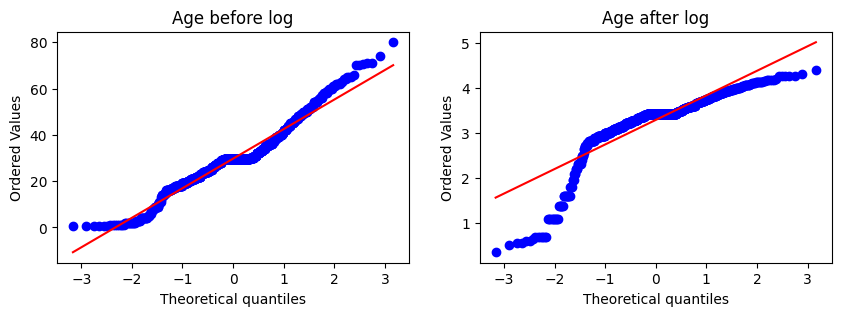

In [85]:
fig, axes = plt.subplots(1,2, figsize=(10,3))

stats.probplot(x['Age'], dist="norm", plot=axes[0])
axes[0].set_title("Age before log")

stats.probplot(x_transformed['Age'], dist="norm", plot=axes[1])
axes[1].set_title("Age after log")

plt.show()

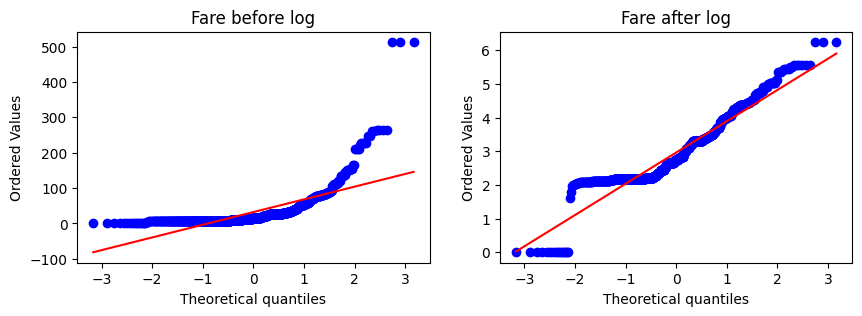

In [86]:
fig, axes = plt.subplots(1,2, figsize=(10,3))

stats.probplot(x['Fare'], dist="norm", plot=axes[0])
axes[0].set_title("Fare before log")

stats.probplot(x_transformed['Fare'], dist="norm", plot=axes[1])
axes[1].set_title("Fare after log")

plt.show()

#### - Clearly see that <b>Fare</b> column is more better after log transform where <b>Age</b> column is not.

### Apply transformation on Fare not on Age

In [95]:
trf2 = ColumnTransformer([('log', FunctionTransformer(func=np.log1p), ['Fare'])], remainder='passthrough')

In [96]:
x_train_trnsfrd2 = trf2.fit_transform(x_train)
x_test_trnsfrd2 = trf2.fit_transform(x_test)

In [97]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [98]:
clf.fit(x_train_trnsfrd2, y_train)
clf2.fit(x_train_trnsfrd2, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [99]:
y_pred = clf.predict(x_test_trnsfrd2)
y_pred2 = clf2.predict(x_test_trnsfrd2)

In [100]:
print("Accuracy LR", accuracy_score(y_pred, y_test))
print("Accuracy DT", accuracy_score(y_pred2, y_test))

Accuracy LR 0.6368715083798883
Accuracy DT 0.6089385474860335


In [102]:
# Cross validation
x_transformed2 = trf2.fit_transform(x)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
print("Accuracy LR", cross_val_score(clf, x_transformed2, y, cv=10, scoring='accuracy').mean())
print("Accuracy DT", cross_val_score(clf2, x_transformed2, y, cv=10, scoring='accuracy').mean())

Accuracy LR 0.6712609238451936
Accuracy DT 0.6610861423220974


### Defining a function to find accuracy for different mathematical function

In [108]:
def apply_transform(funct):
    x = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('func', FunctionTransformer(funct), ['Fare'])],remainder='passthrough')

    x_trans = trf.fit_transform(x)

    clf = LogisticRegression()
    
    print("Accuracy", cross_val_score(clf, x_trans, y, cv=8, scoring='accuracy').mean())

    
    fig, axes = plt.subplots(1,2, figsize=(10,3))
    stats.probplot(x['Fare'], dist='norm', plot=axes[0])
    axes[0].set_title('Fare before transform')

    stats.probplot(x_trans[:,0], dist='norm', plot=axes[1])
    axes[1].set_title('Fare after transform')
    plt.show()

Accuracy 0.6172779922779923


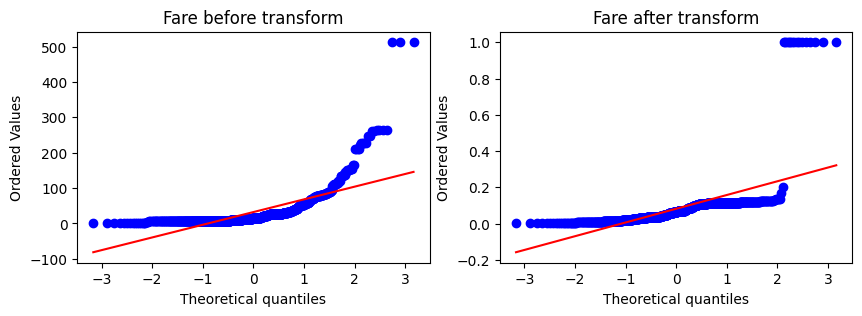

In [123]:
apply_transform(lambda x: 1/(x+1))